# Candidate second axes for a 4mu background plane: mass equality, charge pairing, vertex DCA

**Where this fits.** The 4mu background estimate uses windowed sideband fits
(notebooks 04-05) because every two-variable ABCD plane tried so far fails to
factorize: the channel offers only two families of variables -- event
kinematics (isolation, mJJ, angles) and muon reconstruction (displacement,
DSA content, vertex quality) -- and any pair drawn from the same family
shares a latent variable, which biases the ABCD identity. The 2mu2e channel
escaped because its EGM leg is a third, independent family.

**What this study tests.** Three handles that live in structure a
combinatoric background does not have, and that no previous plane used:

1. **Mass equality** `dmrel = |m0-m1|/(m0+m1)` of the two muon lepton-jet
   dimuon masses. Two decays of the *same* dark photon give equal masses at
   any mass point -- no mass scan needed; combinatoric pairs are broad.
2. **Charge pairing** `qbal` = how many of the two leading mu-LJs are
   exactly-2-muon *same-sign* pairs. A dark photon decay is strictly
   opposite-sign (up to charge mis-assignment); lepton-jets with a third
   clustered muon or a surviving PF/DSA duplicate track are deliberately not
   tagged, so the same-sign label stays pure.
3. **Vertex DCA** `vdca` = the Kalman-fit 3D distance of closest approach of
   the best within-LJ dimuon vertex. Two tracks from a common decay point
   intersect; a fake pairing of unrelated tracks does not.

**The data.** A dedicated full-Run2018 pass (14402/14418 chunks: DoubleMuon
data in the window-blinded channels, the 4Mu signal grid, and the background
MC set; condor output tag `AbcdPairRes_Run2018_v1`, recorded for provenance).
Data histograms carry the candidate axis x both isolation categories x vertex
category x pixel content x fine mJJ, so each candidate's independence from the
deployed variables is measured on the open sidebands -- the blind windows
stay blinded throughout.

In [1]:
import glob, math, re
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import coffea.util as cu

plt.style.use(hep.style.CMS)

D = "/uscms_data/d3/murtazas/abcd_pairres_local"
HNAMES = ("abcd_dmrel_4mu", "abcd_qbal_4mu", "abcd_vdca_4mu")

def load(pattern):
    out = {}
    for f in sorted(glob.glob(D + "/" + pattern)):
        o = cu.load(f); o = o.get("out", o)
        for ds in o.values():
            for k in HNAMES:
                h = ds["hists"][k]
                out[k] = h.copy() if k not in out else out[k] + h
    return out

DATA = load("DoubleMuon_*.coffea")

def arr(hists, hname, ch):
    hch = hists[hname][{"channel": ch}]
    names = [a.name for a in hch.axes]
    v = hch.view()
    v = v["value"] if v.dtype.names else v
    i = names.index("parity"); v = v.sum(axis=i); names.pop(i)
    return v, names

def red(v, names, keep, sel=None):
    sl = [slice(None)] * v.ndim
    for k, s in (sel or {}).items():
        sl[names.index(k)] = s
    vv = v[tuple(sl)]
    return vv.sum(axis=tuple(i for i, n in enumerate(names) if n not in keep))

MJ = np.asarray(DATA["abcd_dmrel_4mu"].axes["mjjf"].edges)
CTR = 0.5 * (MJ[:-1] + MJ[1:]); CTR[-1] = 1000.
BLIND = ((CTR >= 80) & (CTR < 130)) | ((CTR >= 380) & (CTR < 600)) | (CTR >= 780)
OPEN = ~BLIND

# candidate-axis "pass" definitions (axis 0 of each hist)
PASS = {"abcd_dmrel_4mu": ("dmrel", slice(0, 3), "dmrel < 0.2"),
        "abcd_qbal_4mu": ("qbal", slice(0, 1), "no SS-tagged LJ"),
        "abcd_vdca_4mu": ("vdca", slice(1, 5), "vertex with DCA < 0.05 cm")}

def kappa2x2(v, names, axname, apass, extra=None, mrange=None):
    m = OPEN.copy()
    if mrange is not None:
        m &= (CTR >= mrange[0]) & (CTR < mrange[1])
    keep = [axname, "muiso0c", "muiso1c", "mjjf"]
    full = red(v, names, keep=keep, sel=extra or {})
    kn = [n for n in names if n in keep]
    full = np.moveaxis(full, kn.index("mjjf"), -1)[..., m].sum(axis=-1)
    o3 = [n for n in kn if n != "mjjf"]
    full = np.transpose(full, [o3.index(axname), o3.index("muiso0c"), o3.index("muiso1c")])
    ap = np.zeros(full.shape[0], bool); ap[apass] = True
    iso = np.zeros((3, 3), bool); iso[0:2, 0:2] = True
    A = full[ap][:, iso].sum(); B = full[~ap][:, iso].sum()
    Cc = full[ap][:, ~iso].sum(); Dd = full[~ap][:, ~iso].sum()
    if min(A, B, Cc, Dd) <= 0:
        return None, None, (A, B, Cc, Dd)
    k = A * Dd / (B * Cc)
    return k, k * math.sqrt(1 / A + 1 / B + 1 / Cc + 1 / Dd), (A, B, Cc, Dd)
print("loaded %d data files" % len(glob.glob(D + "/DoubleMuon_*.coffea")))

loaded 68 data files


## 1. Does any candidate factorize against isolation?

For each candidate we form the 2x2 plane (candidate pass/fail) x (both
mu-LJs isolated / not) over the **open sideband** mJJ bins and compute

$$\kappa = \frac{N_{\rm pass,iso}\,N_{\rm fail,\overline{iso}}}{N_{\rm fail,iso}\,N_{\rm pass,\overline{iso}}},$$

which equals 1 exactly when the plane factorizes (a usable ABCD). Errors are
the log-normal propagation of the four Poisson counts.

**The row that matters is the vertex-cleaned one.** The raw sample is
dominated by the no-vertex instrumental artifact, and a mixture of two
populations can fake kappa ~ 1 unconditionally while each population alone
does not factorize -- the same dilution trap that inflated early iso x iso
closure tests (notebook 02). Any real 4mu plane would be built *after* the
within-LJ vertex requirement, so the `vcat good` row is the honest test. The
[600,780) row is reported for completeness but its isolation-failing
sideband holds under ten events -- too sparse to conclude anything.

dmrel  (dmrel < 0.2           ) all open   kappa = 0.96 +- 0.02   [A=  8949 B= 22402 C=  3017 D=  7223]
dmrel  (dmrel < 0.2           ) vcat good  kappa = 0.78 +- 0.05   [A=   423 B=  1304 C=  1776 D=  4287]
dmrel  (dmrel < 0.2           ) [130,380)  kappa = 1.02 +- 0.03   [A=  7020 B= 17456 C=  1916 D=  4883]
dmrel  (dmrel < 0.2           ) [600,780)  kappa = 6.22 +- 6.42   [A=  1872 B=  4812 C=     1 D=    16]

qbal   (no SS-tagged LJ       ) all open   kappa = 1.40 +- 0.03   [A= 17597 B= 13754 C=  4885 D=  5355]
qbal   (no SS-tagged LJ       ) vcat good  kappa = 1.38 +- 0.08   [A=  1028 B=   699 C=  3133 D=  2930]
qbal   (no SS-tagged LJ       ) [130,380)  kappa = 1.22 +- 0.03   [A= 12597 B= 11879 C=  3168 D=  3631]
qbal   (no SS-tagged LJ       ) [600,780)  kappa = 4.03 +- 1.99   [A=  4936 B=  1748 C=     7 D=    10]

vdca   (vertex with DCA < 0.05 cm) all open   kappa = 0.00 +- 0.00   [A=   236 B= 31115 C=  6266 D=  3974]
vdca   (vertex with DCA < 0.05 cm) vcat good  kappa = 0.06 

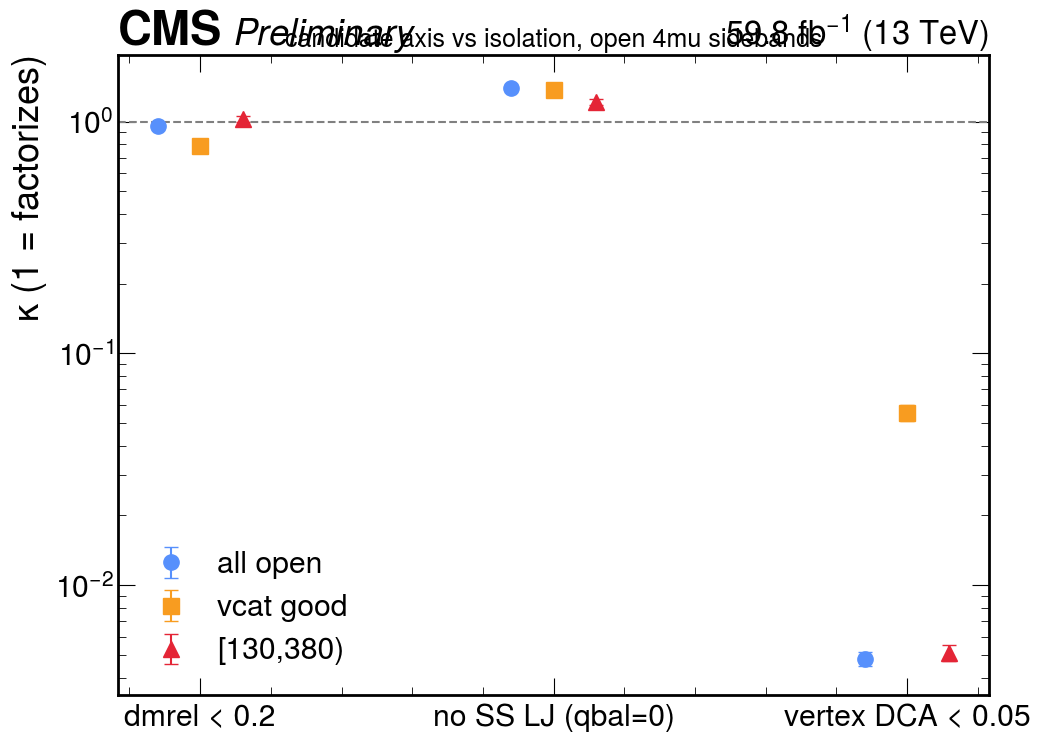

In [2]:
ROWS = (("all open", None, None), ("vcat good", {"vcat": slice(1, 2)}, None),
        ("[130,380)", None, (130., 380.)), ("[600,780)", None, (600., 780.)))
KAP = {}
for hname, (axname, apass, desc) in PASS.items():
    v, names = arr(DATA, hname, "4mu_abcd_scan_data_win")
    for tag, extra, mrange in ROWS:
        k, dk, cells = kappa2x2(v, names, axname, apass, extra, mrange)
        KAP[(axname, tag)] = (k, dk, cells)
        cs = "A=%6d B=%6d C=%6d D=%6d" % cells
        print("%-6s (%-22s) %-10s kappa = %s   [%s]"
              % (axname, desc, tag, ("%.2f +- %.2f" % (k, dk)) if k else "undefined", cs))
    print()

fig, ax = plt.subplots(figsize=(11, 8))
xs = np.arange(3)
for i, (tag, mk) in enumerate((("all open", "o"), ("vcat good", "s"), ("[130,380)", "^"))):
    ks = [KAP[(a, tag)][0] for a in ("dmrel", "qbal", "vdca")]
    es = [KAP[(a, tag)][1] for a in ("dmrel", "qbal", "vdca")]
    ax.errorbar(xs + 0.12 * (i - 1), ks, yerr=es, fmt=mk, ms=11, capsize=5, label=tag)
ax.axhline(1.0, color="gray", ls="--")
ax.set_xticks(xs); ax.set_xticklabels(["dmrel < 0.2", "no SS LJ (qbal=0)", "vertex DCA < 0.05"])
ax.set_ylabel(r"$\kappa$ (1 = factorizes)"); ax.set_yscale("log")
ax.set_title("candidate axis vs isolation, open 4mu sidebands", fontsize=18)
ax.legend(); hep.cms.label("Preliminary", data=True, lumi=59.8, ax=ax)
plt.tight_layout(); plt.show()

**Reading the table.** None of the three factorizes where it matters:

* **dmrel** is the best second axis ever measured in 4mu -- vertex-cleaned
  kappa = 0.78 +- 0.05, against 1.59 (best cross plane) to 1.83 (iso x iso)
  for every earlier plane tried in notebook 02 -- but this is still a failed
  independence test: kappa = 0.78 means the ABCD identity would over-predict
  region A by 1/0.78 - 1 ~ 28%. The unconditional 0.96 is exactly the
  dilution accident the cleaned row unmasks (Simpson's paradox: the no-vertex
  and good-vertex populations have kappa 1.19 and 0.78, and their mixture
  lands at 0.96 -- closer to 1 than either component alone).
* **qbal** correlates strongly with isolation (kappa ~ 1.4 in every
  well-populated slice): the same-sign rate tracks DSA content, which tracks
  the isolation sentinel. Not an ABCD axis -- but see Section 3 for what it
  *is* good for.
* **vdca** is not an independent axis at all (kappa ~ 0 by construction: the
  no-vertex artifact owns the isolated side). It is a *cleaning* variable in
  the same family as the vertex-quality requirement.

The two-family obstruction stands: 4mu has no second independent axis, and
the windowed sideband fit (notebooks 04-05) remains the background method.

## 2. Signal cost across the grid

Efficiency of each candidate's pass requirement for every simulated 4Mu
point (events entering the 4mu preselection; MC scan channel, no blinding).
Mass and lifetime both drive the physics:

* **dmrel** efficiency is set by dimuon-mass resolution, which degrades two
  ways. *Lifetime*: at the nominal 1.2 GeV dark photon it falls from ~0.9-1.0
  prompt to ~0.2-0.5 displaced, because displaced decays are reconstructed
  with DSA muons whose momentum resolution smears the mass -- equal true
  masses stop looking equal (the pixel-content split shows the same trend for
  the PF subsample). *Mass*: a light 0.25 GeV dark photon is collimated and
  low-mass, so its efficiency is already ~0.24 even prompt, while a heavy
  5 GeV point stays ~0.6-0.7 even at 8 mm. Mass equality is therefore a
  discriminant only for heavy dark photons at short lifetime -- the opposite
  corner from where a displaced search needs it most.
* **qbal=0** stays at 0.81-1.00 across the grid: charge mis-assignment costs
  a few percent for well-measured muons, rising to ~15-19% at the softest,
  most displaced points (the cost that matters for the veto below).
* **vdca < 0.05 cm** decays from 0.92-0.98 (prompt) to 0.2-0.35 (long
  lifetime): the DCA resolution of muon-system-only fits degrades with
  displacement. This is unlike the chi2 < 5 vertex requirement, whose signal
  efficiency is *flat* in lifetime (measured 56-72% across the 1.9-96 mm grid
  in the vertex study) -- so a tight DCA cut would trade away displaced signal
  where the flat chi2 cut does not. It stays a diagnostic, not a selection.

4Mu_1000GeV_1p2GeV_0p0096mm        n=173955  dmrel<0.2 0.87 (PF 0.88 / DSA 0.78)   qbal=0 0.98   vdca<0.05 0.92
4Mu_1000GeV_1p2GeV_0p96mm          n=82776  dmrel<0.2 0.38 (PF 0.52 / DSA 0.32)   qbal=0 0.89   vdca<0.05 0.55
4Mu_1000GeV_1p2GeV_9p6mm           n= 4202  dmrel<0.2 0.25 (PF 0.26 / DSA 0.25)   qbal=0 0.81   vdca<0.05 0.35
4Mu_100GeV_1p2GeV_0p096mm          n=43975  dmrel<0.2 0.98 (PF 0.98 / DSA 0.94)   qbal=0 1.00   vdca<0.05 0.98
4Mu_100GeV_1p2GeV_96p0mm           n= 3326  dmrel<0.2 0.32 (PF 0.30 / DSA 0.32)   qbal=0 0.91   vdca<0.05 0.22
4Mu_100GeV_1p2GeV_9p6mm            n=25001  dmrel<0.2 0.48 (PF 0.67 / DSA 0.44)   qbal=0 0.96   vdca<0.05 0.53


4Mu_500GeV_0p25GeV_0p4mm           n=127536  dmrel<0.2 0.24 (PF 0.30 / DSA 0.22)   qbal=0 0.92   vdca<0.05 0.39
4Mu_500GeV_0p25GeV_4p0mm           n= 7264  dmrel<0.2 0.21 (PF 0.12 / DSA 0.22)   qbal=0 0.88   vdca<0.05 0.24
4Mu_500GeV_1p2GeV_0p019mm          n=207793  dmrel<0.2 0.93 (PF 0.94 / DSA 0.85)   qbal=0 1.00   vdca<0.05 0.95
4Mu_500GeV_1p2GeV_19p0mm           n=12107  dmrel<0.2 0.26 (PF 0.28 / DSA 0.26)   qbal=0 0.89   vdca<0.05 0.29
4Mu_500GeV_1p2GeV_1p9mm            n=127426  dmrel<0.2 0.41 (PF 0.57 / DSA 0.36)   qbal=0 0.94   vdca<0.05 0.53
4Mu_500GeV_5p0GeV_80p0mm           n=10586  dmrel<0.2 0.44 (PF 0.59 / DSA 0.43)   qbal=0 0.89   vdca<0.05 0.33
4Mu_500GeV_5p0GeV_8p0mm            n=98218  dmrel<0.2 0.73 (PF 0.84 / DSA 0.69)   qbal=0 0.96   vdca<0.05 0.62


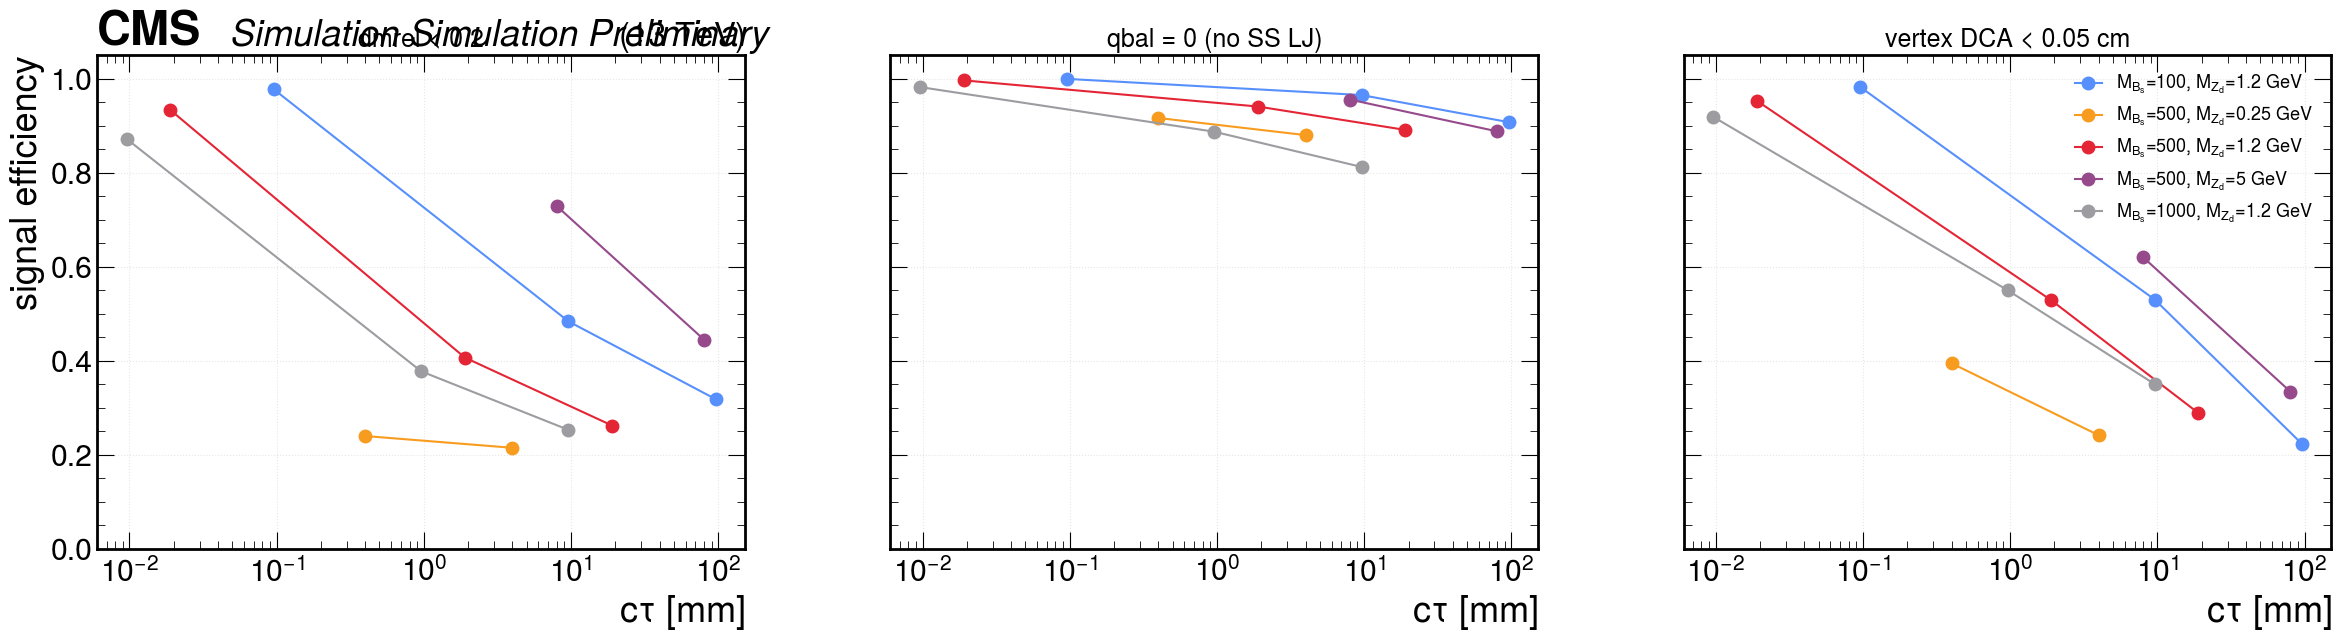

In [3]:
def ptok(t): return float(t.replace("p", "."))
def parse(name):
    m = re.match(r"4Mu_(\d+)GeV_([0-9p]+)GeV_([0-9p]+)mm", name)
    return int(m.group(1)), ptok(m.group(2)), ptok(m.group(3))

SIG = {}
for f in sorted(glob.glob(D + "/4Mu_*.coffea")):
    name = f.split("/")[-1].replace(".coffea", "")
    S = load(name + ".coffea")
    row = {}
    for hname, (axname, apass, desc) in PASS.items():
        v, names = arr(S, hname, "4mu_abcd_scan")
        tot = red(v, names, keep=[axname]).sum()
        row[axname] = float(red(v, names, keep=[axname])[apass].sum() / tot) if tot else None
        row["n"] = float(tot)
    v, names = arr(S, "abcd_dmrel_4mu", "4mu_abcd_scan")
    for lab, sl in (("pf", slice(1, 2)), ("dsa", slice(0, 1))):
        e = red(v, names, keep=["dmrel"], sel={"pix0": sl})
        row["dmrel_" + lab] = float(e[0:3].sum() / e.sum()) if e.sum() else None
    SIG[name] = row
    print("%-34s n=%5.0f  dmrel<0.2 %.2f (PF %.2f / DSA %.2f)   qbal=0 %.2f   vdca<0.05 %.2f"
          % (name, row["n"], row["dmrel"], row["dmrel_pf"] or -1, row["dmrel_dsa"] or -1,
             row["qbal"], row["vdca"]))

fig, axs = plt.subplots(1, 3, figsize=(24, 7), sharey=True)
series = {}
for name, row in SIG.items():
    mb, mdp, ct = parse(name)
    series.setdefault((mb, mdp), []).append((ct, row))
for (mb, mdp), pts in sorted(series.items()):
    pts.sort()
    cts = [p[0] for p in pts]
    for ax, key in zip(axs, ("dmrel", "qbal", "vdca")):
        ax.plot(cts, [p[1][key] for p in pts], "o-", ms=9,
                label=r"$M_{B_s}$=%d, $M_{Z_d}$=%.2g GeV" % (mb, mdp))
for ax, ttl in zip(axs, ("dmrel < 0.2", "qbal = 0 (no SS LJ)", "vertex DCA < 0.05 cm")):
    ax.set_xscale("log"); ax.set_xlabel(r"$c\tau$ [mm]"); ax.set_title(ttl, fontsize=18)
    ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)
axs[0].set_ylabel("signal efficiency"); axs[2].legend(fontsize=13)
hep.cms.label("Simulation Preliminary", data=False, ax=axs[0])
plt.tight_layout(); plt.show()

## 3. What the full-Run2018 data found: the fit region is 40% same-sign

The instrumental artifact was already known to be dominated by fake dimuons
with no within-LJ vertex, which the vertex requirement removes -- 90% of the
isolated population here has no vertex (printed below). At full statistics the
data adds its charge anatomy: in the isolated, *no-vertex* population the
same-sign fraction is 45%, and -- the useful part -- even in the
**vertex-cleaned fit region** (good vertex + both LJs isolated, the exact
spectrum the windowed fits run on) **40% of events carry a same-sign-tagged
lepton-jet** (699 of 1727 open-sideband events), while signal is
same-sign-tagged in only <1% to 19% of events (Section 2).

A `qbal = 0` requirement in the 4mu selection would remove ~40% of the
background under every window (assuming the sideband same-sign fraction
carries under the blind windows -- a smoothness assumption of the same kind
the fits already make, checkable per sideband). Its value depends strongly on
lifetime, because the signal cost does: the expected 95% CL limit in this
background-limited regime scales as sqrt(1 - f_bkg) / (1 - f_sig) =
sqrt(0.6) / (1 - f_sig). With f_sig a few percent for prompt/heavy-dark-photon
signal this is a ~20% improvement; with f_sig ~ 0.15-0.19 at the long-lifetime
points the search targets it shrinks to a few percent. Net-positive across the
grid, but concentrated where the search is already strong. The same-sign
events also form a signal-free control region for the residual background
shape.

**This is a selection change, not a bookkeeping change**: adopting it means
amending the frozen prescription (notebook 05) and re-freezing the
backgrounds on the qbal=0 spectra. It is presented here as a measured
recommendation and deliberately *not* applied to any result in this series.

artifact proxy (isolated, no vertex)       qbal 0/1/2 =  15648 /  8860 / 3699   SS-tagged 44.5%
FIT REGION (isolated, good vertex)         qbal 0/1/2 =   1028 /   420 /  279   SS-tagged 40.5%
all 4mu preselection                       qbal 0/1/2 =  22482 / 13966 / 5143   SS-tagged 45.9%


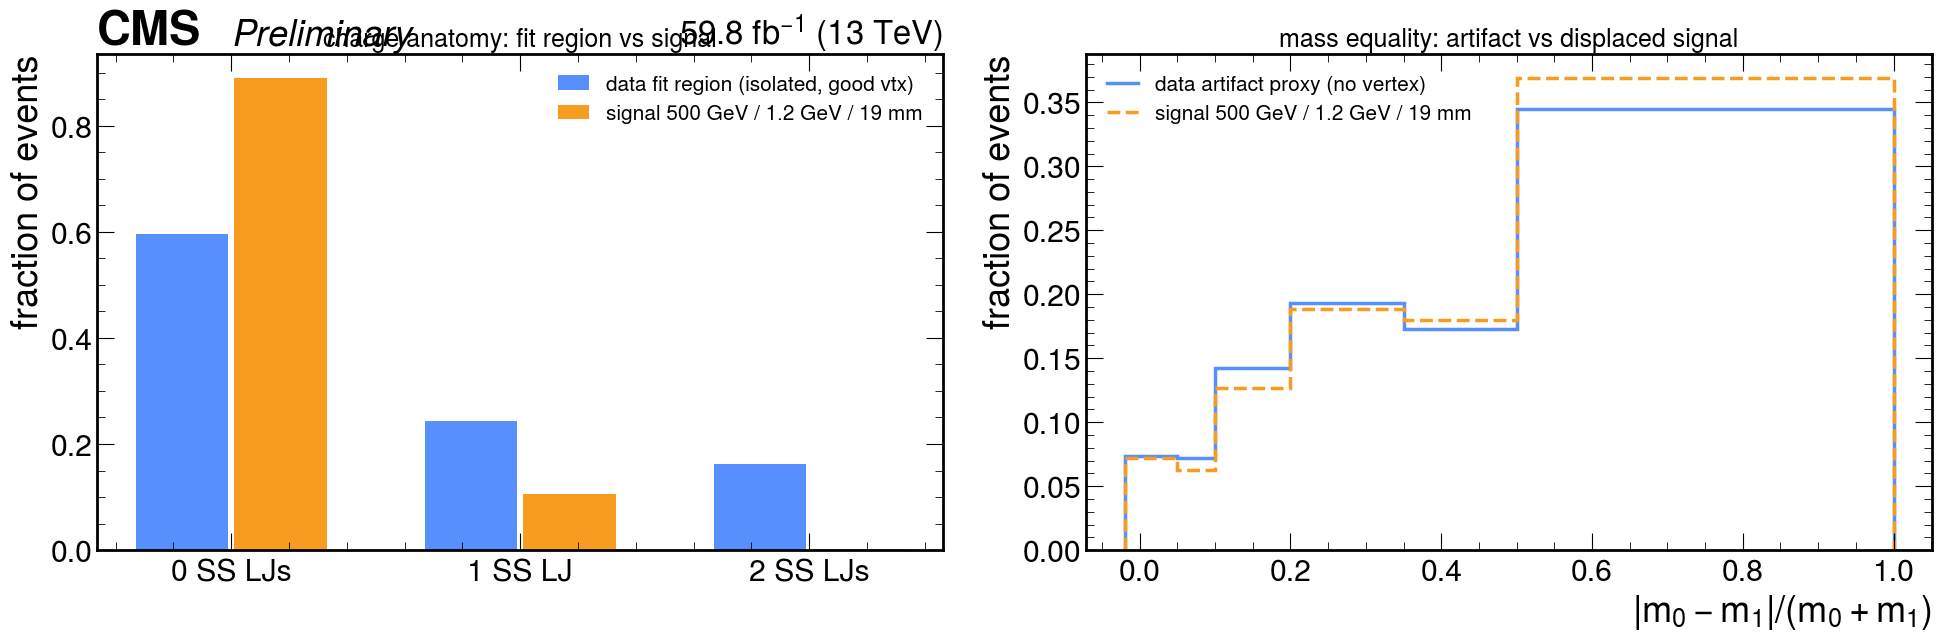

In [4]:
v, names = arr(DATA, "abcd_qbal_4mu", "4mu_abcd_scan_data_win")
ISO = {"muiso0c": slice(0, 2), "muiso1c": slice(0, 2)}

def qfrac(sel, label):
    q = red(v, names, keep=["qbal", "mjjf"], sel=sel)[:, OPEN].sum(axis=1)
    print("%-42s qbal 0/1/2 = %6d /%6d /%5d   SS-tagged %.1f%%"
          % (label, q[0], q[1], q[2], 100 * q[1:].sum() / q.sum()))
    return q

q_art = qfrac({**ISO, "vcat": slice(0, 1)}, "artifact proxy (isolated, no vertex)")
q_fit = qfrac({**ISO, "vcat": slice(1, 2)}, "FIT REGION (isolated, good vertex)")
q_all = qfrac({}, "all 4mu preselection")

vd, nd = arr(DATA, "abcd_dmrel_4mu", "4mu_abcd_scan_data_win")
S19 = load("4Mu_500GeV_1p2GeV_19p0mm.coffea")
vs, ns = arr(S19, "abcd_dmrel_4mu", "4mu_abcd_scan")
dm_art = red(vd, nd, keep=["dmrel", "mjjf"], sel={**ISO, "vcat": slice(0, 1)})[:, OPEN].sum(axis=1)
dm_sig = red(vs, ns, keep=["dmrel"])
DME = [-0.02, 0.05, 0.1, 0.2, 0.35, 0.5, 1.0]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(20, 7))
a1.bar(np.arange(3) - 0.17, q_fit / q_fit.sum(), 0.32, label="data fit region (isolated, good vtx)")
sq = red(*arr(S19, "abcd_qbal_4mu", "4mu_abcd_scan"), keep=["qbal"])
a1.bar(np.arange(3) + 0.17, sq / sq.sum(), 0.32, label=r"signal 500 GeV / 1.2 GeV / 19 mm")
a1.set_xticks(range(3)); a1.set_xticklabels(["0 SS LJs", "1 SS LJ", "2 SS LJs"])
a1.set_ylabel("fraction of events"); a1.legend(fontsize=15)
a1.set_title("charge anatomy: fit region vs signal", fontsize=18)
a2.stairs(dm_art / dm_art.sum(), DME, lw=2.5, label="data artifact proxy (no vertex)")
a2.stairs(dm_sig / dm_sig.sum(), DME, lw=2.5, ls="--", label="signal 500 GeV / 1.2 GeV / 19 mm")
a2.set_xlabel(r"$|m_0-m_1|/(m_0+m_1)$"); a2.set_ylabel("fraction of events")
a2.set_title("mass equality: artifact vs displaced signal", fontsize=18)
a2.legend(fontsize=15)
hep.cms.label("Preliminary", data=True, lumi=59.8, ax=a1)
plt.tight_layout(); plt.show()

## Takeaways

* **The three structural candidates all fail** -- consistent with the
  two-family argument (Section 0), though the universal claim rests on that
  argument, not on three measurements alone. Mass equality, charge pairing,
  and vertex DCA were the handles a combinatoric background should not share
  with isolation; the vertex-cleaned independence tests reject all three
  (kappa = 0.78 +- 0.05, ~1.4, ~0 respectively). No second independent axis
  was found; the windowed sideband fit stays the 4mu background method,
  exactly as frozen in notebook 05.
* **dmrel is the closest miss** and remains a heavy-dark-photon, short-lifetime
  discriminant: signal efficiency ~0.9-1.0 prompt at 1.2 GeV but ~0.2-0.5
  displaced (DSA momentum resolution smears the mass), and already ~0.24 for a
  prompt light 0.25 GeV point (collimation) -- the opposite corner from a
  displaced search's target.
* **The actionable find is the same-sign veto**: 40% of the vertex-cleaned
  fit region is same-sign-tagged, against a <1-19% signal rate -- a potential
  expected-limit gain of ~20% for prompt/heavy signal that shrinks to a few
  percent at the long-lifetime target points (where the veto costs ~15-19% of
  signal). Offered as a recommendation that would require re-freezing the
  backgrounds, and left unapplied here.
* **vertex DCA** adds artifact rejection only at short lifetime (its signal
  efficiency falls with displacement, unlike the lifetime-flat chi2
  requirement) -- kept as a diagnostic.
* The 2mu2e mass-equality mirror (all three deployed-plane legs plus dmrel)
  is in the same output set for future use; the settled 2mu2e ABCD estimate
  does not need it.